# Digital Divide Analysis: GDP vs Internet Adoption


Key insights: 
- GDP per capita strongly predicts internet adoption
- Some countries outperform expectations given income
- Other countries underperform, suggesting structural barriers

In [120]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell

In [121]:
internet_usage = pd.read_csv("data/internet_usage.csv", skiprows=1)
gdp = pd.read_csv("data/gdp_per_capita.csv", skiprows=4)
region_income = pd.read_csv("data/country_metadata.csv")

### Data Inspection

In [122]:
internet_usage.columns = ["Country Code", "Region/Country/Area", "Year", "Series", "Value", "Footnotes", "Source"]
internet_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country Code         1552 non-null   int64  
 1   Region/Country/Area  1552 non-null   object 
 2   Year                 1552 non-null   int64  
 3   Series               1552 non-null   object 
 4   Value                1552 non-null   float64
 5   Footnotes            1033 non-null   object 
 6   Source               1552 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 85.0+ KB


In [123]:
gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

In [124]:
region_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   Region        217 non-null    object 
 2   IncomeGroup   215 non-null    object 
 3   SpecialNotes  130 non-null    object 
 4   TableName     265 non-null    object 
 5   Unnamed: 5    0 non-null      float64
dtypes: float64(1), object(5)
memory usage: 12.6+ KB


Outliers for GDP per capita have stayed consistent over the years. Lichtenstein and Monaco have had GDP per capita over 100000 since 2005, and they've been the two biggest outliers every year since then for the years being studied.

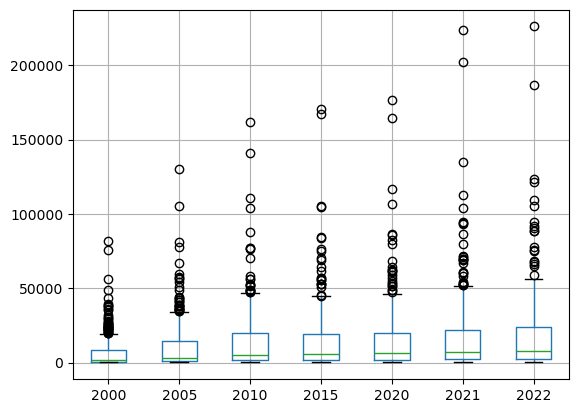

,Country Name,2000,2005,2010,2015,2020,2021,2022
27,Bermuda,56542.956946,77628.103523,104111.824245,104855.366822,106976.546240,112765.081673,121613.939984
111,Ireland,26334.567205,50933.021610,48679.402682,64311.823468,86622.506725,103961.976351,105234.511568
137,Liechtenstein,76087.911114,105295.057028,141089.812849,167187.157310,164671.093553,201944.830335,186821.881757
144,Luxembourg,48659.598875,80988.137623,110885.991379,105462.012584,116860.028172,134965.815442,123719.658916
149,Monaco,81789.020652,130538.742587,161853.920622,170437.101188,176891.886538,223823.363960,226052.001905
177,Norway,38178.236878,67047.170456,88163.208593,74809.965805,68340.018103,93072.892512,109269.520580


In [125]:
gdp[["2000", "2005", "2010", "2015", "2020", "2021", "2022"]].boxplot()
plt.show();
outliers = gdp[(gdp[["2000", "2005", "2010", "2015", "2020", "2021", "2022"]] >= 100000).any(axis=1)]
outliers[["Country Name", "2000", "2005", "2010", "2015", "2020", "2021", "2022"]]


### Data Cleaning

I renamed columns in region_income for clarity and consistency when merging, selected relevant variables, and removed irrelevant fields. 

In [126]:
region_income = region_income.rename(columns={'IncomeGroup': 'Income Group',
 'TableName': 'Country/Territory Name'})
region_income = region_income[["Region", "Income Group", "Country/Territory Name"]]

I selected relevant columns for GDP per capita data aligned with internet usage data and standardized column names.

In [127]:
gdp_1 = gdp[["Country Name", "2000", "2005", "2010", "2015", "2020", "2021", "2022"]]
gdp_1 = gdp_1.rename(columns = {"Country Name": "Country/Territory Name"})

I converted the gdp_1 dataframe from wide form to long form.

In [128]:
col = gdp_1.columns[1:]
gdp_1 = (pd.melt(gdp_1, id_vars = ["Country/Territory Name"], value_vars = col, var_name = "Year", value_name = "GDP Per Capita"))
gdp_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1862 entries, 0 to 1861
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Territory Name  1862 non-null   object 
 1   Year                    1862 non-null   object 
 2   GDP Per Capita          1799 non-null   float64
dtypes: float64(1), object(2)
memory usage: 43.8+ KB


Here, I converted the "Year" column in gdp_1 from an object to an int64 datatype.

In [129]:
gdp_1["Year"]= gdp_1["Year"].astype(int)

Again, I renamed and standardized columns in internet_usage for consistency in merging. I selected analysis-relevant fields from internet_usage and removed unessential fields. 

In [130]:
internet_usage = internet_usage.rename(columns={'Region/Country/Area': 'Country/Territory Name', 'Value': "Percentage of Individuals Using the Internet"})
internet_usage = internet_usage[["Country/Territory Name", "Year", "Percentage of Individuals Using the Internet"]]

I standardized country names across datasets for merge consistency and verified changes before and after standardization.

In [131]:
internet_usage_original = internet_usage["Country/Territory Name"].copy()

internet_usage["Country/Territory Name"] = internet_usage["Country/Territory Name"].replace({"Bahamas": "Bahamas, The","Bolivia (Plurin. State of)": "Bolivia",
"Côte d’Ivoire": "Cote d'Ivoire", "Dem. Rep. of the Congo": "Congo, Dem. Rep.","Congo": "Congo, Rep.","Egypt": "Egypt, Arab Rep.", "Micronesia": "Micronesia, Fed. Sts.",
"Gambia": "Gambia, The","China, Hong Kong SAR": "Hong Kong SAR, China","Iran (Islamic Republic of)": "Iran, Islamic Rep.", "Kyrgyzstan": "Kyrgyz Republic",
"Saint Kitts and Nevis":"St. Kitts and Nevis", "Republic of Korea":"Korea, Rep.", "Lao People's Dem. Rep.": "Lao PDR","Saint Lucia": "St. Lucia","China, Macao SAR": "Macao SAR, China",
"Netherlands (Kingdom of the)": "Netherlands","Puerto Rico": "Puerto Rico (US)","State of Palestine": "West Bank and Gaza","Somalia": "Somalia, Fed. Rep.",
"Slovakia": "Slovak Republic", "Türkiye": "Turkiye", "United Rep. of Tanzania": "Tanzania", "United States of America": "United States",
"Saint Vincent & Grenadines": "St. Vincent and the Grenadines","Venezuela (Boliv. Rep. of)": "Venezuela, RB", "United States Virgin Islands": "Virgin Islands (U.S.)",
"Yemen": "Yemen, Rep.","Total, all countries or areas": "World"})

internet_usage_original.compare(internet_usage["Country/Territory Name"])


,self,other
0,"Total, all countries or areas",World
1,"Total, all countries or areas",World
2,"Total, all countries or areas",World
3,"Total, all countries or areas",World
4,"Total, all countries or areas",World
...,...,...
1512,Yemen,"Yemen, Rep."
1513,Yemen,"Yemen, Rep."
1514,Yemen,"Yemen, Rep."
1515,Yemen,"Yemen, Rep."


I did an inner merge between gdp_1 and internet_usage on 'Country/Territory Name' and 'Year' to create a new dataframe called combined_df.

In [132]:
combined_df = pd.merge(gdp_1, internet_usage, on=['Country/Territory Name', 'Year'], how='inner')

I did a left merge between combined_df and region_income on "Country/Territory Name." 

In [133]:
combined_df = pd.merge(combined_df, region_income, on =["Country/Territory Name"], how = "left")
combined_df = combined_df[["Year", "Country/Territory Name", "Region", "Percentage of Individuals Using the Internet", "GDP Per Capita", "Income Group"]]
combined_df.head()


,Year,Country/Territory Name,Region,Percentage of Individuals Using the Internet,GDP Per Capita,Income Group
0,2000,Aruba,Latin America & Caribbean,15.4,20681.023027,High income
1,2000,Angola,Sub-Saharan Africa,0.1,563.733796,Lower middle income
2,2000,Albania,Europe & Central Asia,0.1,1160.420471,Upper middle income
3,2000,Andorra,Europe & Central Asia,10.5,21810.248743,High income
4,2000,United Arab Emirates,Middle East & North Africa,23.6,29865.502347,High income


Below, I decided to add binning to divide up internet use. I made three groups, low, medium, and high internet use. 

In [134]:
combined_df['Internet Use Bins'] = pd.cut(combined_df['Percentage of Individuals Using the Internet'], 3, labels = [ 'Low Internet Use', 'Medium Internet Use', 'High Internet Use'])
combined_df['Internet Use Bins'].value_counts()

Internet Use Bins
Low Internet Use       597
High Internet Use      480
Medium Internet Use    278
Name: count, dtype: int64

I extracted global internet usage data and merged it by year to enable country-level comparisons against worldwide trends.

In [135]:
world_data = combined_df[combined_df["Country/Territory Name"] == "World"][["Year", "Percentage of Individuals Using the Internet"]]
world_data = world_data.rename(columns={"Percentage of Individuals Using the Internet": "Percentage of Individuals Using the Internet in the World"})
combined_df = pd.merge(combined_df, world_data, on =["Year"], how = "left")

Here, I calculated the ratio by dividing the column: "Percentage of Individuals Using the Internet" by the column: "Percentage of Individuals Using the Internet in the World".

In [136]:
combined_df["Ratio of Internet Users to Global Internet Users"]  = combined_df["Percentage of Individuals Using the Internet"] / combined_df["Percentage of Individuals Using the Internet in the World"]

Here, I decided to add on another column showing the ratio of internet users to GDP per capita.

In [137]:
combined_df["Ratio of Internet Users to GDP"] =  combined_df["Percentage of Individuals Using the Internet"] / combined_df["GDP Per Capita"]

I dropped the extraneous column for percentage of internet users in the world. 

In [138]:
combined_df = combined_df.drop(columns=['Percentage of Individuals Using the Internet in the World'])

Here, I inspected the new columns that I added on. Since there are some countries with 0% of internet users (as found in step 10), it makes sense that there was a min of 0 for both of the two columns. 

In [139]:
combined_df[["Ratio of Internet Users to Global Internet Users","Ratio of Internet Users to GDP" ]].describe()

,Ratio of Internet Users to Global Internet Users,Ratio of Internet Users to GDP
count,1355.000000,1335.000000
mean,1.245376,0.008000
std,1.242833,0.009651
min,0.000000,0.000000
25%,0.432090,0.001682
50%,1.159164,0.004008
75%,1.511692,0.010868
max,9.811321,0.064814


I decided to rename "Country/Territory Name" to "Location" for the sake of simplicity and accuracy. Location also contains world data.

In [140]:
combined_df = combined_df.rename(columns={'Country/Territory Name': 'Location', "Percentage of Individuals Using the Internet": "Percent Internet Users"})

I replaced the nulls in "Income Group" and "Region" with "Unknown" to make it look neat. 

In [141]:
combined_df['Income Group'] = combined_df['Income Group'].fillna('Unknown')
combined_df['Region']=combined_df["Region"].fillna('Unknown')

In [142]:
combined_df.to_csv('combined_df.csv', index=False)

### Exploratory Data Analysis

In [143]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

We can see here that there is signifcant positive skew in GDP Per Capita and Ratio of Internet Users to Global Internet Users. 

In [144]:
combined_df.skew(numeric_only = True)

Year                                               -0.394165
Percent Internet Users                              0.101335
GDP Per Capita                                      3.590305
Ratio of Internet Users to Global Internet Users    3.078262
Ratio of Internet Users to GDP                      2.172833
dtype: float64

Here, I added a new column to combined_df with the log of GDP Per Capita to provide less skewed GDP Per Capita Data.

In [145]:
combined_df['Log GDP Per Capita'] = np.log(combined_df['GDP Per Capita'])
combined_df.skew(numeric_only = True)

Year                                               -0.394165
Percent Internet Users                              0.101335
GDP Per Capita                                      3.590305
Ratio of Internet Users to Global Internet Users    3.078262
Ratio of Internet Users to GDP                      2.172833
Log GDP Per Capita                                 -0.006089
dtype: float64

Here, I decided to create a correlation matrix and heatmap with all relevant numerical fields from combined_df. 

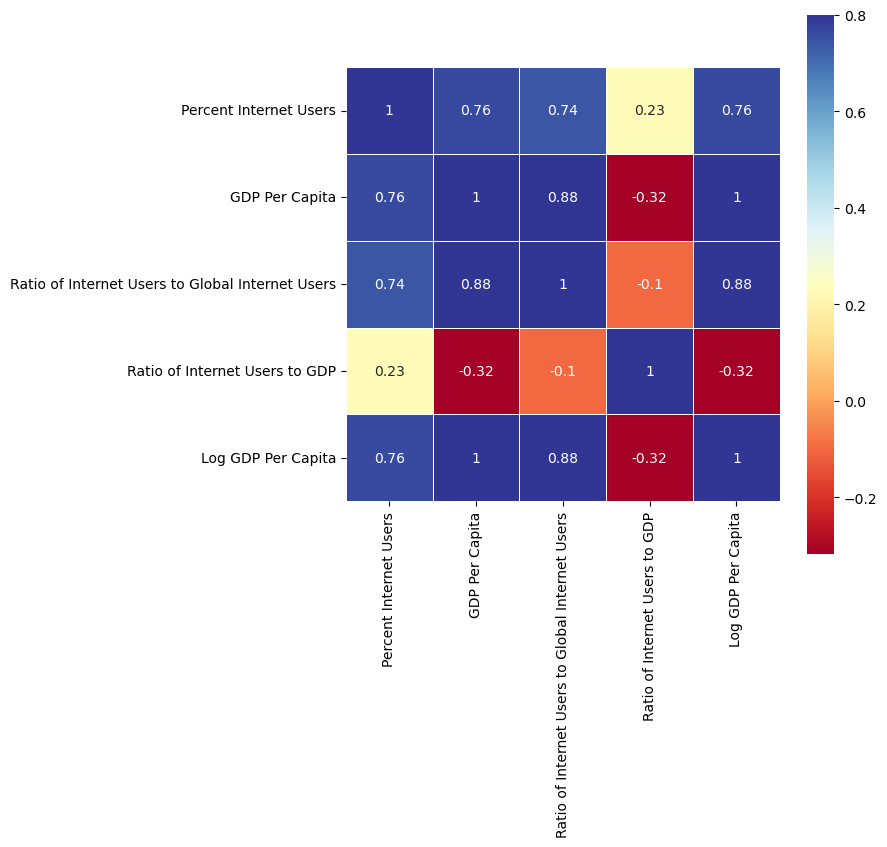

In [146]:
corr_df = combined_df[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat = corr_df.corr(method = 'spearman')
corrmat

f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.show()


Below, I created a new df called world_data with data from the entire world. I also created another df called regional_data, in which I took the median of data from each region for each year. Since my goal for this step is just to look at temporal trends in regional/global data, I filtered out the data for which the region is unknown, before combining the two df's. Lastly, because the rows that have a location of world also have a Region of 'Unknown', I replaced the value from Unknown to World. 

In [147]:
world_data = combined_df[combined_df["Location"] == "World"]
regional_data = combined_df.groupby(['Region', 'Year']).median(numeric_only=True).reset_index()
regional_data = regional_data[regional_data["Region"] != "Unknown"]
regional_data = pd.concat([regional_data, world_data], axis=0)
regional_data['Region'] = regional_data['Region'].replace({'Unknown': 'World'})

The line plots below show how GDP per capita and internet usage changed over time. Here are some interesting observations that I had from this data:
- The rates of change of GDP Per Capita and Percent Internet Users are so different. It looks like the GDP Per Capita has remained relatively constant in much of the world from 2000-2022 with the exception of North America.
- Percent Internet Users has a bit more of an S-shaped curve, and there has been rapid adoption of the internet worldwide from 2000.

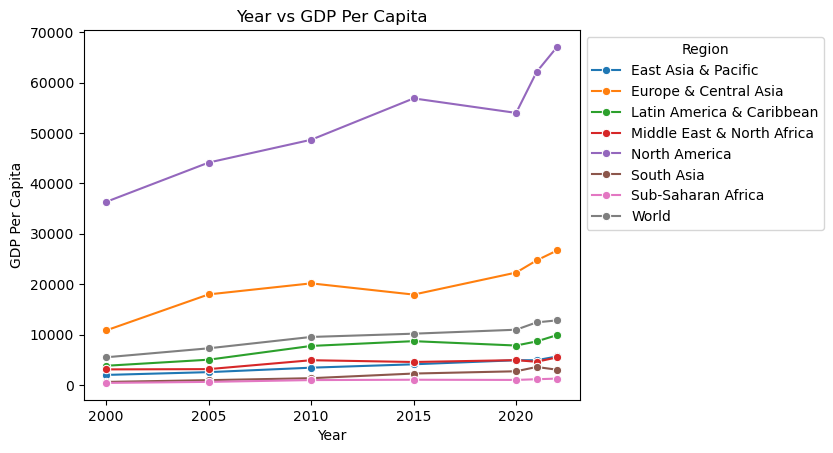

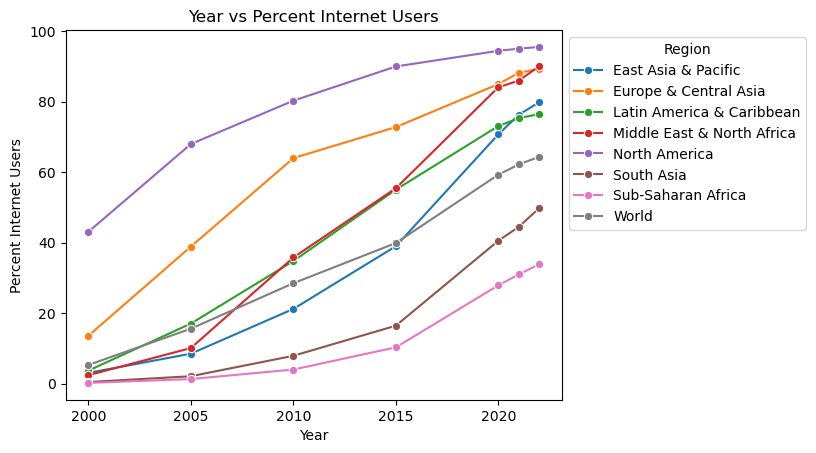

In [148]:
ax = sns.lineplot(data=regional_data, x='Year', y='GDP Per Capita', hue='Region', marker='o')
plt.title('Year vs GDP Per Capita')
plt.xlabel('Year')
plt.ylabel('GDP Per Capita')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show();

ax = sns.lineplot(data=regional_data, x='Year', y='Percent Internet Users',hue='Region', marker='o')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title('Year vs Percent Internet Users')
plt.xlabel('Year')
plt.ylabel('Percent Internet Users')
plt.show();

Here, we can see that there are only 3 locations being sampled the regional classification of North America in our data sample, which is likely why the GDP Per Capita data for North America is so much higher.

In [149]:
x = combined_df.loc[combined_df['Region'] == 'North America']
x["Location"].value_counts()

Location
Canada           7
United States    7
Bermuda          4
Name: count, dtype: int64

Here, I went ahead and made similar heatmaps for each of the indivudal years being studied. The heatmaps are presented in order of year from earliest to latest.  Here are some observations: 
- Each year being studied had a high positive correlation between GDP Per Capita and Percent Internet Usage, with the lowest correlation being 0.89.
- There weren't any differences b/w correlation scores for Log GDP Per Capita vs. those for GDP Per Capita.
- It's noteworthy that the overall correlation b/w GDP Per Capita and Percent Internet Usage from combined_df was 0.76, which is lower than that of each of the individual years. This makes sense since many years were being combined in combined_df.
- The correlation between the ratio of internet users to GDP and percent internet users gradually went from positive to strongly negative over the years. This makes a lot of sense. As countries became increasingly saturated in their percent of internet users, the GDP Per Capita increases outpaced the internet usage increases, leading to an inverse relationship between these two variables.
- The same trend was seen b/w the ratio of internet users to GDP and the GDP Per capita as well as b/w the ratio of internet users to GDP and Ratio of Internet Users to Global Internet Users. We can see that in earlier years, there was more rapid growth in internet usage than in GDP Per capita, but that changed overtime.

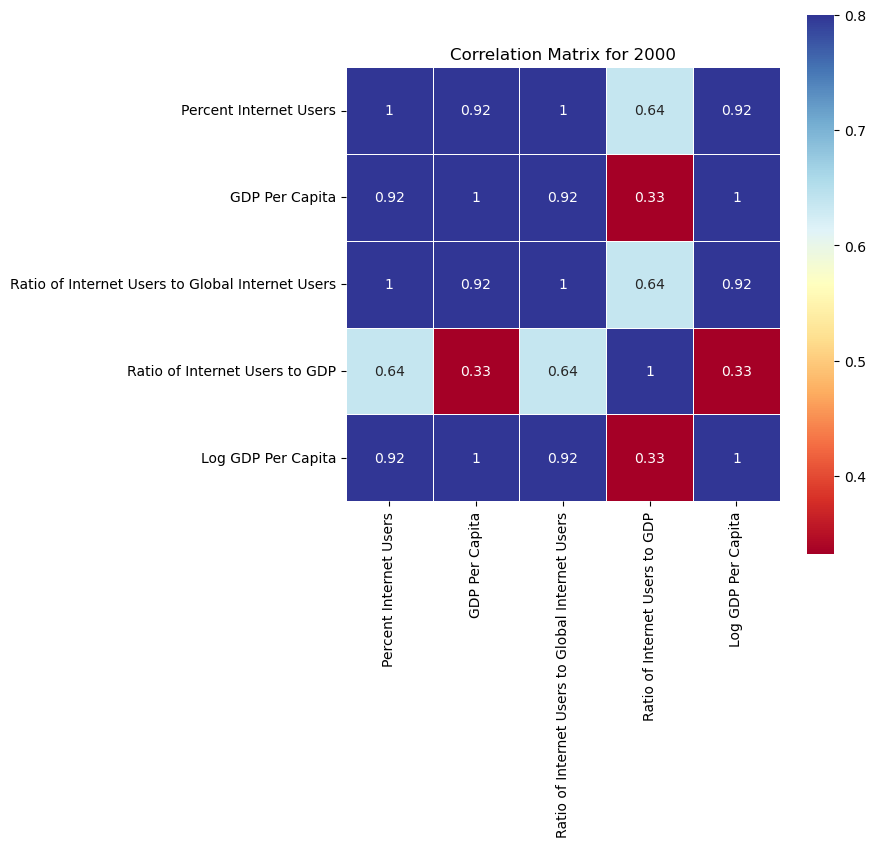

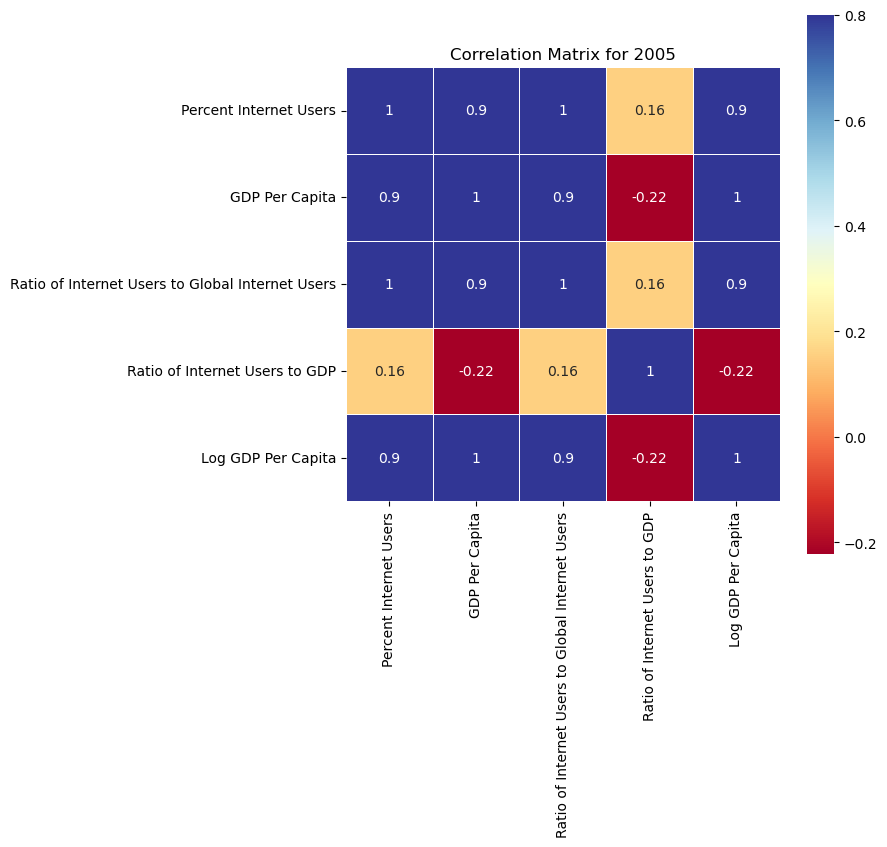

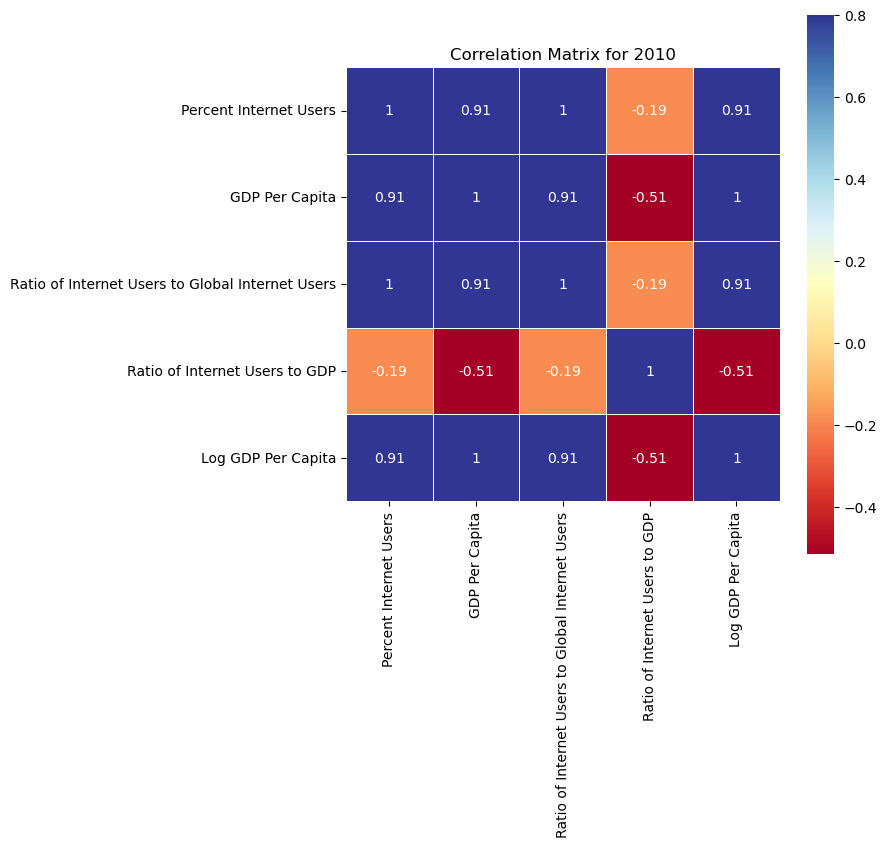

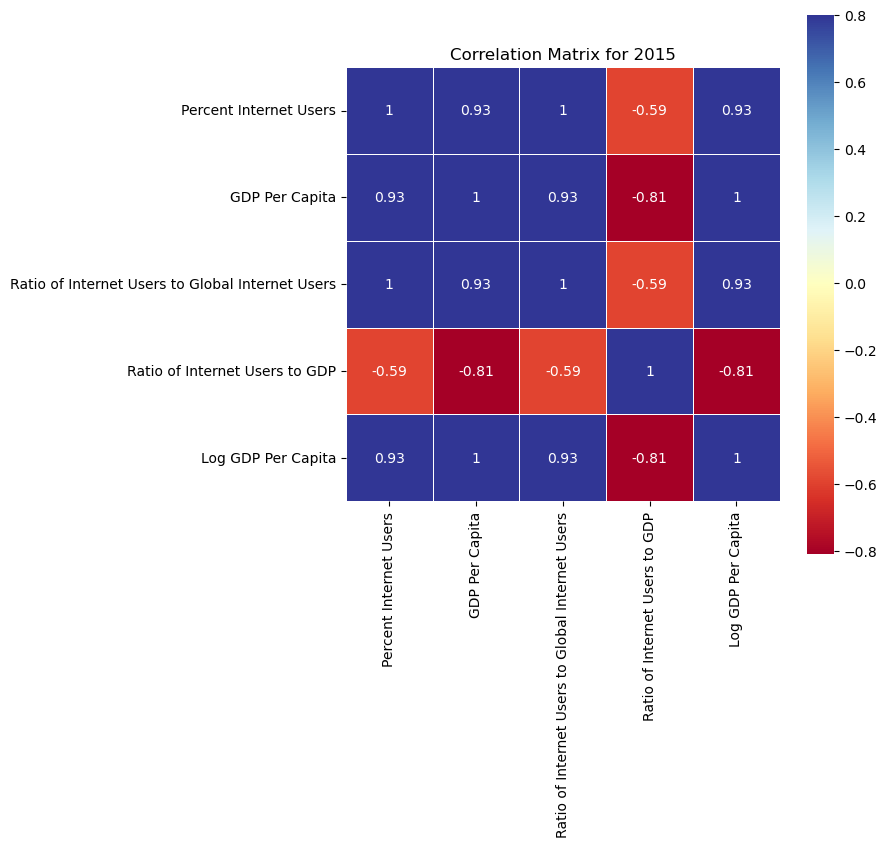

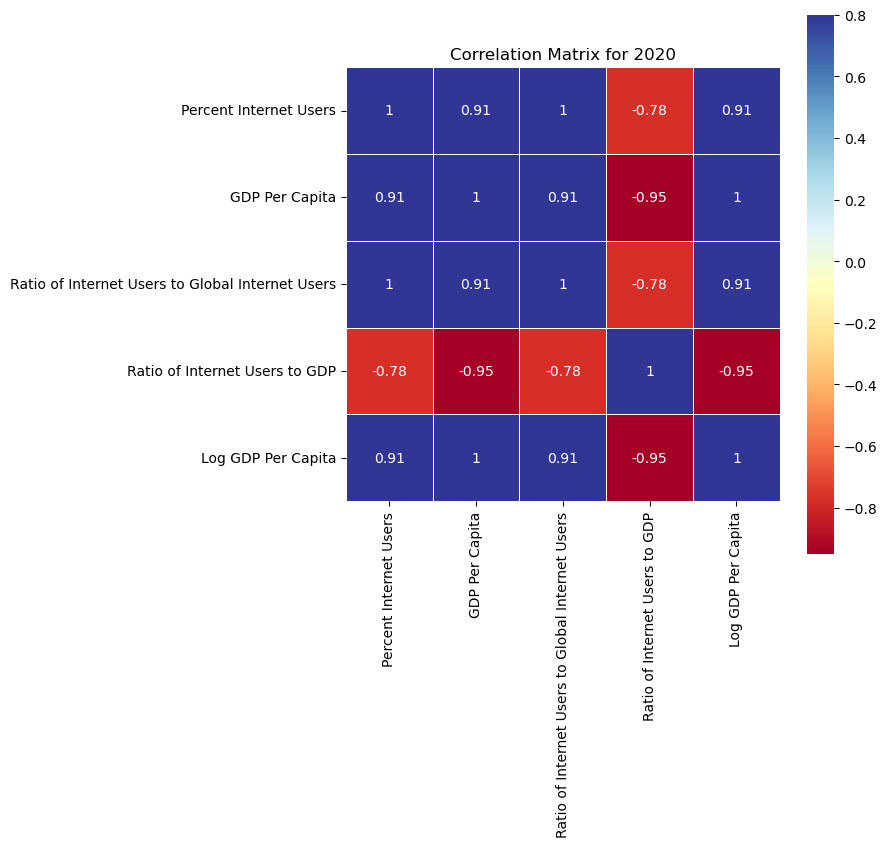

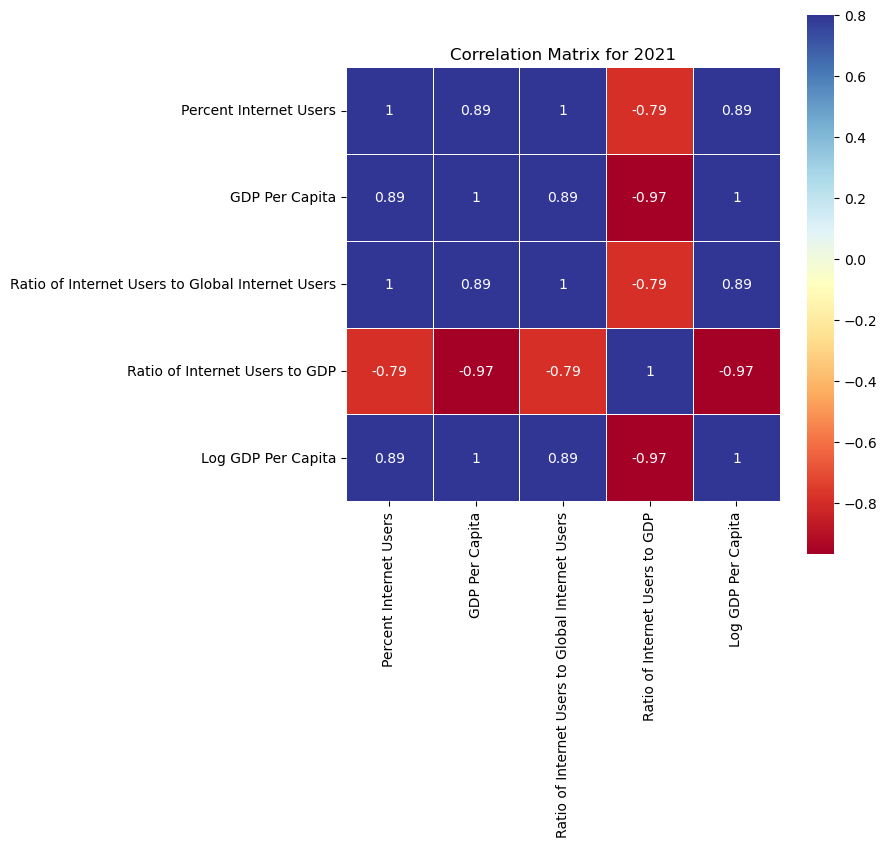

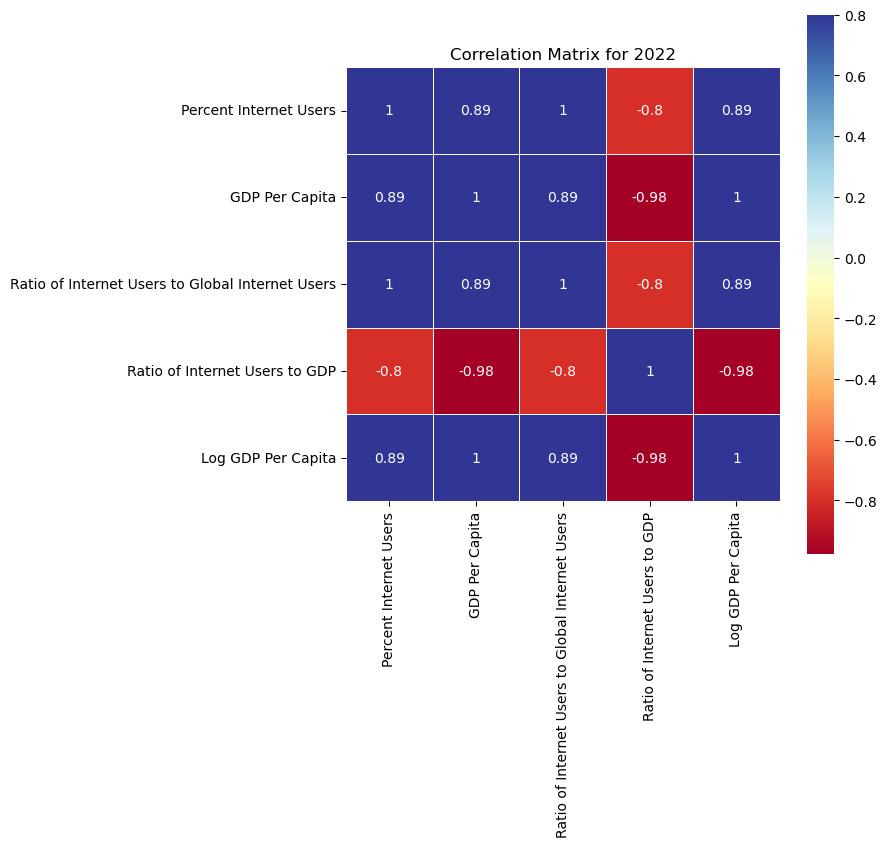

In [150]:
data_2000 = combined_df[combined_df["Year"] == 2000]
corr_df_2000 = data_2000[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2000.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2000')
plt.show();




data_2005 = combined_df[combined_df["Year"] == 2005]
corr_df_2005 = data_2005[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2005.corr(method = 'spearman')

f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2005')
plt.show();



data_2010 = combined_df[combined_df["Year"] == 2010]
corr_df_2010 = data_2010[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2010.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2010')
plt.show();




data_2015 = combined_df[combined_df["Year"] == 2015]
corr_df_2015 = data_2015[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2015.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2015')
plt.show();



data_2020 = combined_df[combined_df["Year"] == 2020]
corr_df_2020 = data_2020[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2020.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2020')
plt.show();



data_2021 = combined_df[combined_df["Year"] == 2021]
corr_df_2021 = data_2021[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2021.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2021')
plt.show();



data_2022 = combined_df[combined_df["Year"] == 2022]
corr_df_2022 = data_2022[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2022.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2022')
plt.show();


Here, I made a df for each year filtering out locations with unknown income groups. 

In [151]:
data_2022 = combined_df[combined_df["Year"] == 2022]
data_2022 = data_2022[data_2022["Income Group"] != "Unknown"]

data_2021 = combined_df[combined_df["Year"] == 2021]
data_2021 = data_2021[data_2021["Income Group"] != "Unknown"]

data_2020 = combined_df[combined_df["Year"] == 2020]
data_2020 = data_2020[data_2020["Income Group"] != "Unknown"]

data_2015 = combined_df[combined_df["Year"] == 2015]
data_2015 = data_2015[data_2015["Income Group"] != "Unknown"]

data_2010 = combined_df[combined_df["Year"] == 2010]
data_2010 = data_2010[data_2010["Income Group"] != "Unknown"]

data_2005 = combined_df[combined_df["Year"] == 2005]
data_2005 = data_2005[data_2005["Income Group"] != "Unknown"]

data_2000 = data_2000[data_2000["Income Group"] != "Unknown"]

Here, I created a faceted violin plot showing the distribution of internet usage by income 
group across all years being studied. Some observations:
- From 2000-2005, there's a massive amount of variation in internet usage amongst high 
  income countries, and much lower amounts of variation shown in non-high income countries.
- In 2010 and 2015 we can see increases in internet usage across all income groups, and a 
  decrease in variation in internet usage in high income locations. There's also a large 
  increase in the variation of internet usage in lower and upper middle locations during 
  this time.
- After 2015, we begin to see a large lessening of variation amongst upper middle and high 
  income locations, as their internet usage rates are quite high. The internet usage for 
  low income locations still lags significantly, but has made major strides since 2000.

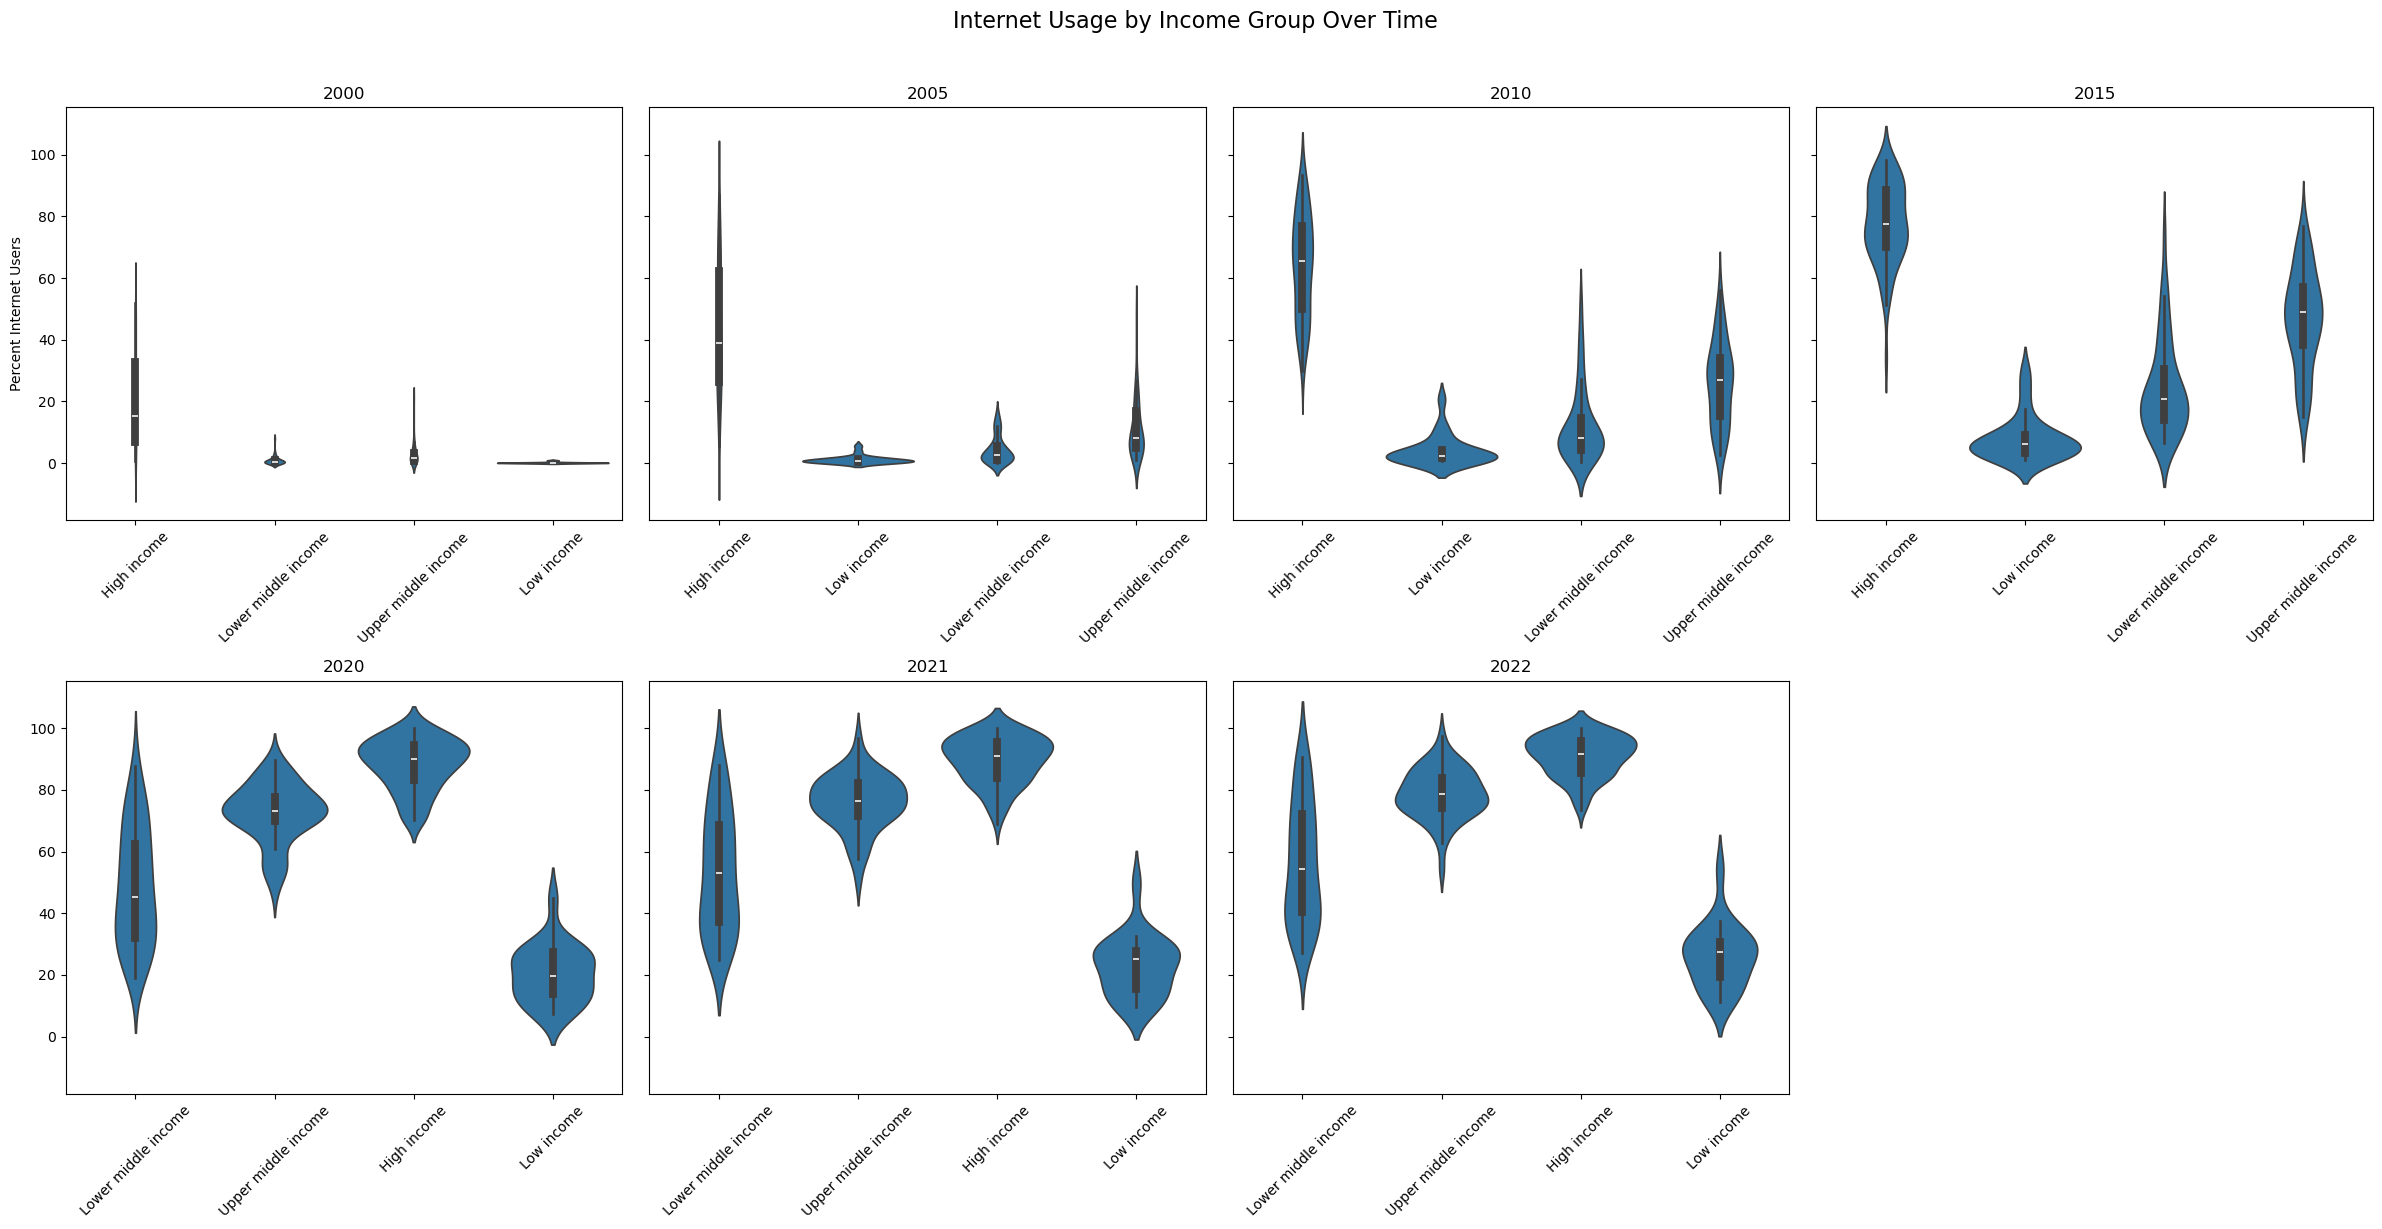

In [152]:
years = [2000, 2005, 2010, 2015, 2020, 2021, 2022]
fig, axes = plt.subplots(2, 4, figsize=(24, 12), sharey=True)

for ax, year in zip(axes.flatten(), years):
    data = combined_df[(combined_df['Year'] == year) & (combined_df['Income Group'] != 'Unknown')]
    sns.violinplot(data=data, x='Income Group', y='Percent Internet Users', ax=ax)
    ax.set_title(str(year))
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Percent Internet Users' if year == 2000 else '')
axes[1, 3].set_visible(False)

fig.suptitle('Internet Usage by Income Group Over Time', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Below, I used the internet use bins to show the overall progression of internet usage across all locations overtime. I used value_counts to see how many locations are present for each bin. This data shows us just how drastic the change is. 0 locations had high internet use and 170 had low internet use for 2000. This is almost flipped for 2022, with 124 locations with high internet use and only 22 locations with low internet use. 

In [153]:
data_2000["Internet Use Bins"].value_counts()
data_2005["Internet Use Bins"].value_counts()
data_2010["Internet Use Bins"].value_counts()
data_2015["Internet Use Bins"].value_counts()
data_2020["Internet Use Bins"].value_counts()
data_2021["Internet Use Bins"].value_counts()
data_2022["Internet Use Bins"].value_counts()

Internet Use Bins
High Internet Use      124
Medium Internet Use     32
Low Internet Use        22
Name: count, dtype: int64

Here, I created a faceted scatterplot showing the relationship between Log GDP Per Capita 
and Percent Internet Users across all years being studied. Some observations:
- The positive relationship between Log GDP Per Capita and Percent Internet Users is 
  consistent across all years, confirming the strong correlation seen in the heatmaps.
- In earlier years (2000, 2005), countries cluster heavily in the bottom-left, reflecting 
  low global internet adoption. By 2022, the distribution shifts rightward and upward.
- Saturation becomes visible in later years, as many countries approach 80–100% internet 
  usage regardless of GDP level, compressing the upper end of the distribution.
- The trendline slope visibly flattens over time, consistent with diminishing returns at 
  higher income levels noted in the regression analysis.

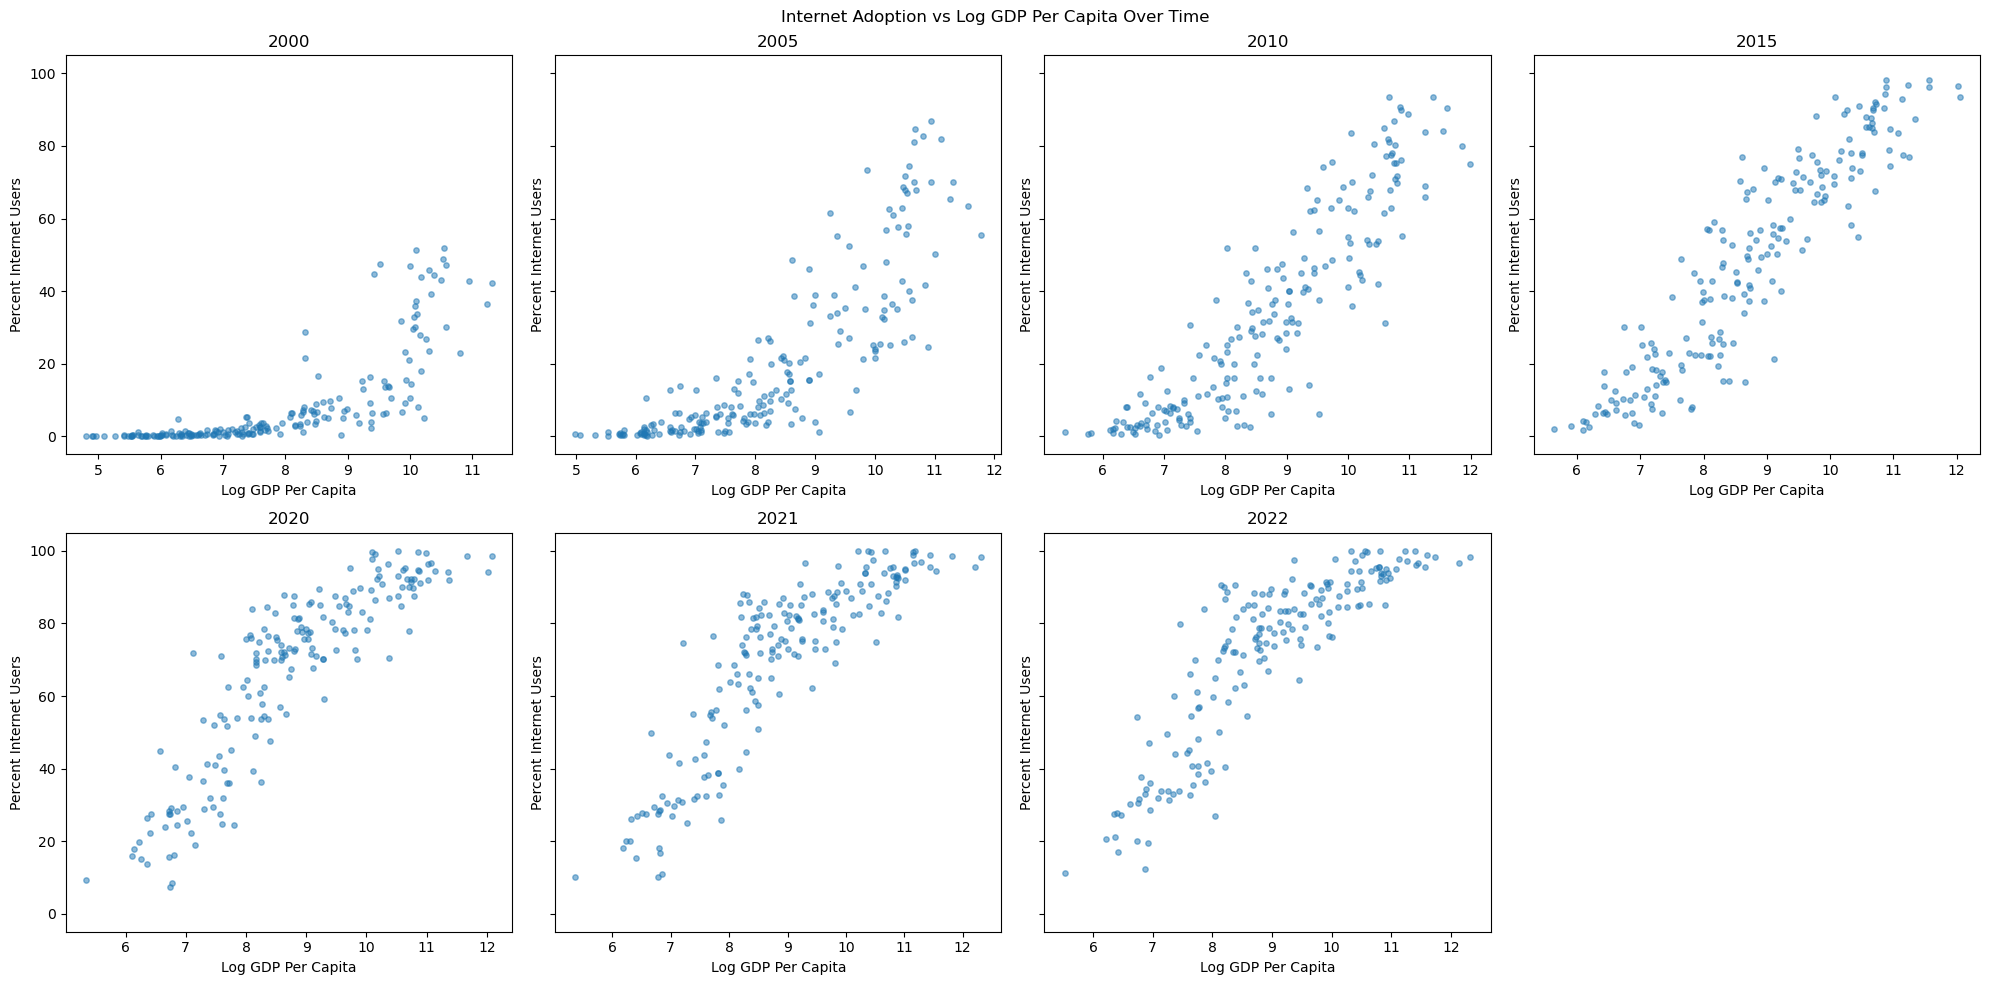

In [154]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
years = [2000, 2005, 2010, 2015, 2020, 2021, 2022]
for ax, year in zip(axes.flatten(), years):
    data = combined_df[combined_df['Year'] == year]
    ax.scatter(data['Log GDP Per Capita'], data['Percent Internet Users'], alpha=0.5, s=15)
    ax.set_title(str(year))
    ax.set_xlabel('Log GDP Per Capita')
    ax.set_ylabel('Percent Internet Users')
fig.suptitle('Internet Adoption vs Log GDP Per Capita Over Time')
axes[1, 3].set_visible(False)
plt.tight_layout()
plt.show()

Here, I created scatterplots for 2022, the most recent year in the dataset. 2022 is the 
focus of the regression-based analysis that follows. Some observations:
- The log-linear relationship between GDP Per Capita and Percent Internet Users is strong 
  and clear, justifying the use of a log-linear regression model.
- Saturation is evident among high-income countries, with many clustered near 90–100% 
  internet usage regardless of further GDP increases.
- Significant spread remains at middle and lower income levels, suggesting that factors 
  beyond GDP — such as infrastructure and policy — play a meaningful role in internet 
  adoption, which the residual analysis below explores further.
- Overall, Sub-Saharan Africa has seen the slowest adoption of the internet out of all global regions, and Europe and Central Asia and North America have shown the quickest.


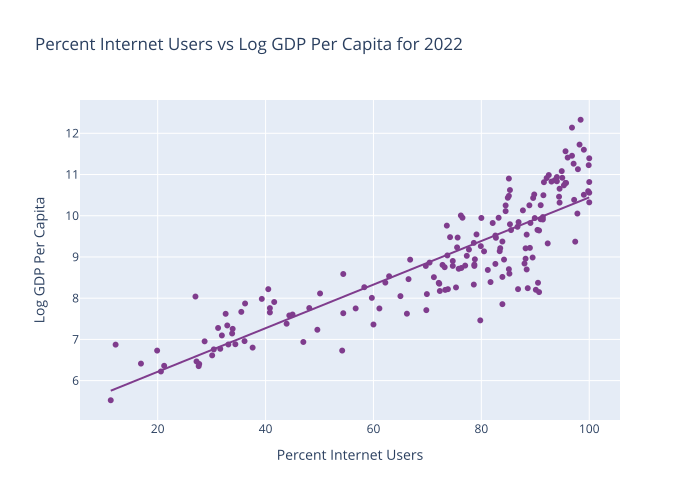

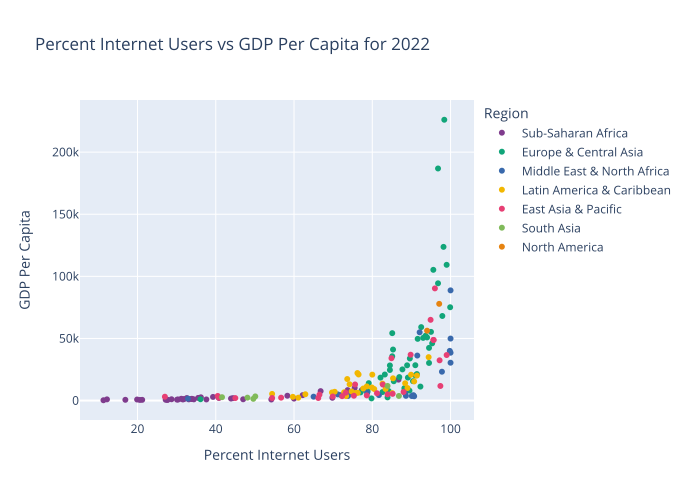

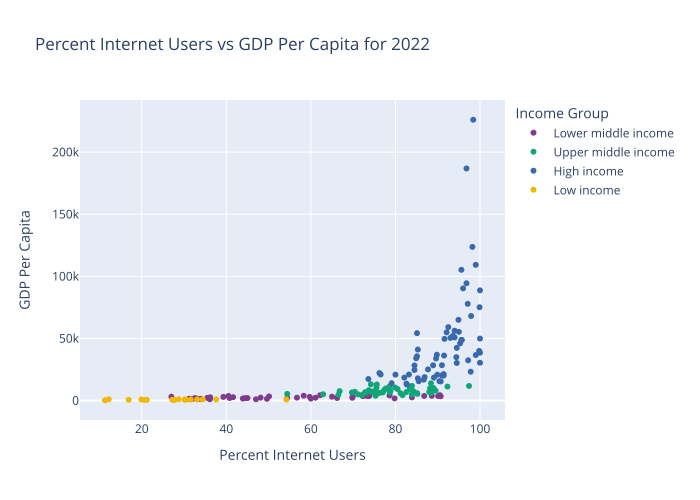

In [155]:
fig = px.scatter(data_2022,  x='Percent Internet Users', y='Log GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs Log GDP Per Capita for 2022',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'Log GDP Per Capita');
fig.show(renderer="svg");



fig = px.scatter(data_2022,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2022',
                 color_discrete_sequence = px.colors.qualitative.Bold, color = "Region")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show(renderer="svg");



fig = px.scatter(data_2022, x = "Percent Internet Users", y = "GDP Per Capita", color = 'Income Group', 
                 size_max = 60,
        title='Percent Internet Users vs GDP Per Capita for 2022', hover_name = 'Location',
                 color_discrete_sequence = px.colors.qualitative.Bold)
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show(renderer="svg");

## Regression-Based Analysis: Expected vs Actual Internet Adoption

In [156]:
df = combined_df[['GDP Per Capita', 'Percent Internet Users', 'Location', 'Year']]
df = df.dropna(subset=['GDP Per Capita', 'Percent Internet Users'])

df['log_gdp'] = np.log(df['GDP Per Capita'])

latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year].copy()

X = sm.add_constant(df_latest['log_gdp'])
y = df_latest['Percent Internet Users']

model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     Percent Internet Users   R-squared:                       0.748
Model:                                OLS   Adj. R-squared:                  0.747
Method:                     Least Squares   F-statistic:                     529.7
Date:                    Tue, 31 Mar 2026   Prob (F-statistic):           3.08e-55
Time:                            19:06:16   Log-Likelihood:                -700.72
No. Observations:                     180   AIC:                             1405.
Df Residuals:                         178   BIC:                             1412.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

In [157]:
df_latest['predicted'] = model.predict(X)
df_latest['residual'] = df_latest['Percent Internet Users'] - df_latest['predicted']

In [158]:
top_over = df_latest.sort_values('residual', ascending=False).head(10)
top_under = df_latest.sort_values('residual', ascending=True).head(10)

print(top_over[['Location', 'Percent Internet Users', 'predicted', 'residual']])
print(top_under[['Location', 'Percent Internet Users', 'predicted', 'residual']])

                Location  Percent Internet Users  predicted   residual
1275             Morocco                    90.7  60.039210  30.660790
1257     Kyrgyz Republic                    79.8  50.176388  29.623612
1264             Lebanon                    90.1  60.843850  29.256150
1345          Uzbekistan                    83.9  55.832791  28.067209
1253              Jordan                    90.5  63.289629  27.210371
1309  West Bank and Gaza                    88.6  61.405378  27.194622
1196              Bhutan                    86.8  61.066185  25.733815
1266               Libya                    88.4  67.938412  20.461588
1290            Malaysia                    97.4  77.628014  19.771986
1225                Fiji                    85.2  66.469512  18.730488
                   Location  Percent Internet Users   predicted   residual
1305       Papua New Guinea                    27.0   58.489866 -31.489866
1333                   Chad                    12.2   41.721169 -29.5

In [159]:
# select top/bottom performers
top_over = df_latest.sort_values('residual', ascending=False).head(3)
top_under = df_latest.sort_values('residual', ascending=True).head(3)
label_df = pd.concat([top_over, top_under])

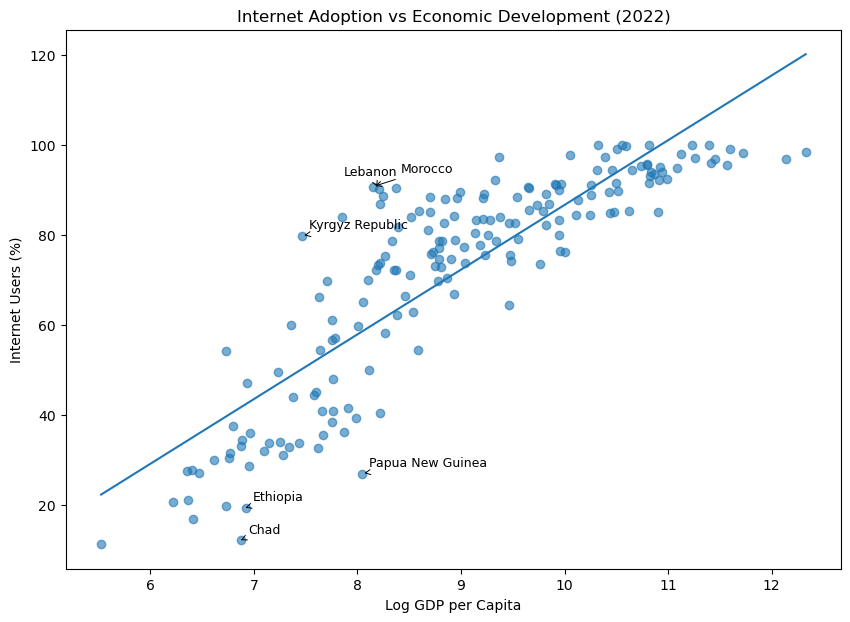

In [160]:
#create the plot 
plt.figure(figsize=(10, 7))

#scatterplot 
plt.scatter(
    df_latest['log_gdp'],
    df_latest['Percent Internet Users'],
    alpha=0.6
)

#regression line 
x_vals = np.linspace(df_latest['log_gdp'].min(), df_latest['log_gdp'].max(), 100)     
intercept = model.params['const'] 
slope = model.params['log_gdp'] 
y_vals = intercept + slope * x_vals 

plt.plot(x_vals, y_vals)

#annotate locations with arrows 
for _, row in label_df.iterrows():
    x = row['log_gdp']
    y = row['Percent Internet Users']
    country = row['Location']

    # manual offsets for overlap cases
    if country == "Morocco":
        offset = (20, 10)
    elif country == "Lebanon":
        offset = (-25, 10)
    else:
        offset = (5, 5)

    plt.annotate(
        country,
        xy=(x, y),
        xytext=offset,
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', lw=0.7),
        fontsize=9
    )

# labels + title
plt.xlabel("Log GDP per Capita")
plt.ylabel("Internet Users (%)")
plt.title("Internet Adoption vs Economic Development (2022)")

plt.show();

- From this regression analysis, we estimate expected internet adoption using a log-linear regression of internet usage on GDP per capita for 2022. This establishes a baseline relationship between economic development and digital connectivity.
- GDP per capita strongly predicts internet adoption, with diminishing returns at higher income levels. However, not all countries lie on this expected trend.
- To quantify this, we compute residuals (actual − predicted):
    - Positive residuals indicate countries outperforming expectations given their income
    - Negative residuals indicate underperformance
- This approach highlights structural differences beyond income, such as infrastructure, policy, and regional factors, allowing us to identify countries that - lead or lag in digital adoption relative to their economic level.

#### Overall Conclusions:
- GDP per capita is a strong predictor of internet adoption, with a clear positive relationship and diminishing returns at higher income levels.
- Despite this, significant variation exists across countries, indicating that income alone does not fully explain digital connectivity.
- Several countries outperform expectations given their economic level, suggesting effective infrastructure, policy, or technology adoption.
- Others underperform relative to their income, highlighting potential gaps in access, investment, or structural barriers.
- Overall, the global digital divide is shaped by both economic development and country-specific factors beyond income.
- GDP Per Capita and Percent of Internet Users were strongly positively correlated for each of the seven years being studied.